<a href="https://colab.research.google.com/github/feodosiya/Classic_ML_hw/blob/main/stat_hw06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="500">

# Домашнее задание 6: параметрические тесты
</center>

**ФИО:** Филоненко Феодосия Юрьевна

## Общая информация

__Дата выдачи:__ 23.04.2025

__Дедлайн:__ 23:59MSK 11.05.2025

In [ ]:
import numpy as np
import pandas as pd

import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns

### Задача №1: Лучше найди себе девушку! (25 баллов)

В этой задаче вам предстоит проверить несколько гипотез на датасете из американского сервиса знакомств. Датасет называется `dating_is_hard.csv`

Колонки датасета:
- `age` - возраст
- `is_heavy_drinker` - алкоголизм в булевом виде
- `height` - рост в дюймах
- `sex` - полов может быть только два - f для женщин и m для мужчин.
- `smokes` - зависимость от табака в булевом виде
- `location` - место жительства
- `offspring` - отношение к детям

Для каждого пункта нужно расписать нулевую и альтернативную гипотезу, описать какой именно критерий вы используете, перечислить предпослыки необходимые для его использования, а также вычислить значение статистики и p-value, если это возможно.

In [ ]:
df = pd.read_csv('data/dating_is_hard.csv')

In [ ]:
df

,Unnamed: 0,age,is_heavy_drinker,height,sex,smokes,location,offspring
0,uid_1,27,False,64,f,True,san francisco california,no opinion
1,uid_2,38,False,65,f,False,oakland california,wants kids
2,uid_3,31,False,70,m,True,san francisco california,does not have kids
3,uid_4,29,False,66,m,False,martinez california,does not have kids
4,uid_5,30,False,69,m,True,san francisco california,no opinion
...,...,...,...,...,...,...,...,...
995,uid_996,18,False,67,m,True,vallejo california,no opinion
996,uid_997,21,False,70,m,False,san francisco california,does not have kids
997,uid_998,30,False,73,m,False,oakland california,does not have kids
998,uid_999,49,False,71,m,False,san francisco california,no opinion


__a) [5 баллов]__ Рост в приложениях для знакомств не проверяют, поэтому можно поставить себе любой и никто не узнает. Посмотрим же, врут ли люди о своём росте.

Проверьте две гипотезы: совпадает ли средний рост мужчин в приложении с их реальным средним ростом и совпадает ли средний рост женщин в приложении с их реальным средним ростом

__P.S.__ Средний рост мы вам не дамим. Ищите сами и приложите ссылку на источник в решении.

**Источник**: Centers for Disease Control and Prevention, CDC, ЦКЗ США — федеральное агентство министерства здравоохранения США
https://www.cdc.gov/nchs/fastats/body-measurements.htm

*Men:*

Height in inches: 69.0

*Women:*

Height in inches: 63.5


In [ ]:
(df.dropna(subset=['height', 'sex']) != df).sum()

,0
Unnamed: 0,0
age,0
is_heavy_drinker,0
height,0
sex,0
smokes,0
location,0
offspring,0


In [ ]:
df['height'] = pd.to_numeric(df['height'], errors='coerce')
df = df.dropna(subset=['height', 'sex'])

In [ ]:
from scipy.stats import ttest_1samp

men_heights = df[df['sex'] == 'm']['height']
women_heights = df[df['sex'] == 'f']['height']

t_men, p_men = ttest_1samp(men_heights, popmean=69.0)
t_women, p_women = ttest_1samp(women_heights, popmean=63.5)

print(f"Мужчины: t = {t_men:.3f}, p-value = {p_men:.3f}")
print(f"Женщины: t = {t_women:.3f}, p-value = {p_women:.3f}")

Мужчины: t = 11.089, p-value = 0.000
Женщины: t = 9.848, p-value = 0.000


In [ ]:
women_heights.mean()

np.float64(64.8325)

__Вывод:__ Даже с учетом того, что средние близки, t-статистика отмечает статистически значимую разницу. Отвергаем нулевую гипотезу о совпадении роста со средним. При этом такая разница не обязательно является значимой практически.

__б) [10 баллов]__ По моим наблюдениям (состоящим из одного человека) мужчин-алкоголиков гораздо больше женщин. В нашем датасете алкоголизмом мы будем считать параметр `is_heavy_drinker`

Проверьте гипотезу: Действительно ли доля мужчин-алкоголиков выше доли женщин-алкоголиков?

In [ ]:
## z-тест
from statsmodels.stats.proportion import proportions_ztest

men = df[df['sex'] == 'm']
women = df[df['sex'] == 'f']

m_obs = [men['is_heavy_drinker'].sum(), women['is_heavy_drinker'].sum()]
n_obs = [len(men), len(women)]

z_stat, p_val = proportions_ztest(m_obs, n_obs, alternative='larger')
print(f"z = {z_stat:.3f}, p = {p_val:.4f}")

z = 0.423, p = 0.3360


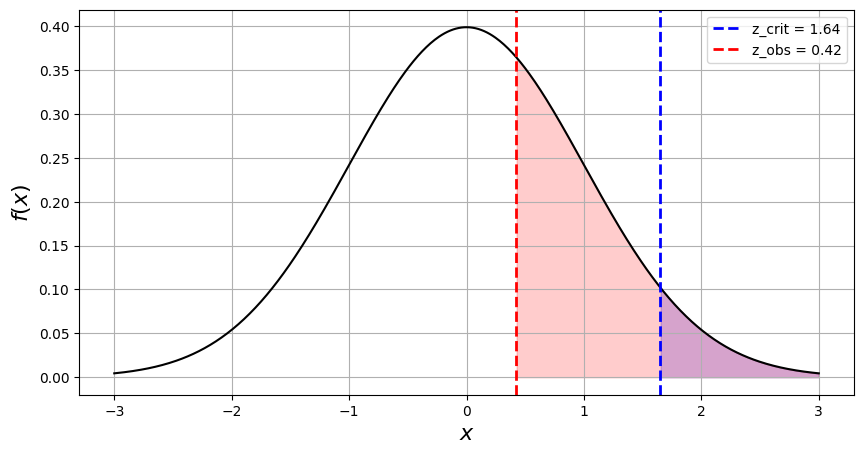

In [ ]:
from scipy.stats import norm

z_crit = norm.ppf(1 - 0.05)

x = np.linspace(-3, 3, 500)
y = norm.pdf(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, color="black")
plt.ylabel("$f(x)$", fontsize=16)
plt.xlabel("$x$", fontsize=16)

plt.axvline(z_crit, color='blue', linestyle='--', lw=2, label=f'z_crit = {z_crit:.2f}')
plt.fill_between(x, 0, y, where=(x >= z_crit), color='blue', alpha=0.2)

plt.axvline(z_stat, color='red', linestyle='--', lw=2, label=f'z_obs = {z_stat:.2f}')
plt.fill_between(x, 0, y, where=(x >= z_stat), color='red', alpha=0.2)

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f'{z_stat:.3} попадает в ({-z_crit:.3} , {z_crit:.3}) => Нулевая гипотеза не отвергается')

0.423 попадает в (-1.64 , 1.64) => Нулевая гипотеза не отвергается


__Вывод:__ p_value очень большое, z-статистика мала. У нас нет оснований отвергать гипотезу о равенстве долей, так что нельзя утверждать, что мужчин-алкоголиков больше.

__в) [10 баллов]__ Мой друг Володька решил бросить курить и теперь курит только когда пьёт. Это навело меня на мысль о том, что курение привлекает алкоголиков сильнее, чем обычных людей.

Проверьте гипотезу: Действительно ли алкоголики больше склонны к курению, чем неалкоголики?

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

alc = df[df['is_heavy_drinker']]
non_alc = df[~df['is_heavy_drinker']]

m_obs = [alc['smokes'].sum(), non_alc['smokes'].sum()]
n_obs = [len(alc), len(non_alc)]

z_stat, p_val = proportions_ztest(m_obs, n_obs, alternative='larger')

print(f"z = {z_stat:.3f}, p-value = {p_val:.4f}")

z = 0.674, p-value = 0.2501


**Вывод:** не можем отвергнуть нулевую гипотезу о равенстве долей (курящие среды алкоголиков и курящие среди не-алкоголиков), потому что наблюдаемая разница статистически мала.

### Задача №2. Тестируем новый интерфейс страницы отеля  (25 баллов)

Все мы любим отдыхать! А злые корпорации любят наживаться на нашем желании отдыхать.

Представим что вы работаете в одной из таких корпораций и занимаетесь аналитикой сайта для бронирования отелей. Процесс бронирования имеет привычную структуру:
- вбиваете в поиск направленния и даты
- получаете выдачу вариантов отелей
- переходите на страницу отеля
- нажимаете кнопку "забронировать"
- попадаете на страницу оплаты
- оплачиваете

Очевидно, на всех этапах этой воронки вы можете потерять пользователя. Поисследовав поведение пользователей вы решили внести изменения на странице об отеле и хотите чтобы выросла конверсия в бронирования

__а) [3 балла]__ Подумайте, какие изменения могли бы быть внесены?

**Ваш ответ:** чтобы выросла конверсия, в теории можно:
* Вынести в выдачу ключевую информацию об отелях (которая оказывается самой существенной на этапе выбора) - например, близость к метро, цена в сутки, включенные услуги
* Изменить визуальную составляющую: фото, разметка
* Сначала выдавать отели с высокими оценками, выводить в выдачу положительные отзывы
* Персонализация

Перед вами датасет `ab_test.csv`, в нем содержатся данные о пользователях в период теста

`user_id` - уникальный идентификатор пользователя \
`sex` - пол пользователя \
`datetime` - дата и время посещения сайта (начала сессии) \
`district` - регион расположения отеля \
`hotel_page` - был ли пользователь на странице отеля в сессии \
`payment_page` - был ли пользователь на странице оплаты в сессии \
`payment` - была ли произведена оплата в сессии \
`group` - группа в эксперименте

Поскольку изменения вносились на странице отеля нас интересуют именно дошедшие до этой страницы пользователи. Поэтому колонка `hotel_page` принимает значение 1 всегда

In [ ]:
df = pd.read_csv("data/ab_simpson.csv")
df.head()

,Unnamed: 0,user_id,sex,datetime,district,hotel_page,payment_page,payment,group
0,0,3326449108867616315,1,11/15/2023 12:02 AM,Южный федеральный округ,1,1,0,control
1,1,7887645543455909870,1,11/02/2023 09:12 PM,Центральный федеральный округ,1,1,0,control
2,2,6148146969124793824,1,11/10/2023 10:06 AM,Центральный федеральный округ,1,1,1,control
3,3,2721602951940155275,0,11/12/2023 07:10 PM,Центральный федеральный округ,1,1,0,control
4,4,1829030712785972138,0,05/01/2024 05:19 AM,Южный федеральный округ,1,0,0,test


__б) [3 балла]__ Сделайте небольшой eda, какие выводы вы можете сделать о данных? Корректно ли проводился аб тест? Найдите ошибки и объясните почему это некорректно.

In [ ]:
df.describe()

,Unnamed: 0,user_id,sex,hotel_page,payment_page,payment
count,401807.000000,4.018070e+05,401807.000000,401807.0,401807.000000,401807.000000
mean,200903.000000,4.615212e+18,0.499994,1.0,0.741824,0.292242
std,115991.834144,2.662886e+18,0.500001,0.0,0.437632,0.454794
min,0.000000,5.888584e+13,0.000000,1.0,0.000000,0.000000
25%,100451.500000,2.309885e+18,0.000000,1.0,0.000000,0.000000
50%,200903.000000,4.610460e+18,0.000000,1.0,1.000000,0.000000
75%,301354.500000,6.923790e+18,1.000000,1.0,1.000000,1.000000
max,401806.000000,9.223335e+18,1.000000,1.0,1.000000,1.000000


In [ ]:
df.group.value_counts(normalize=True) # пользователи распределены равномерно

,proportion
group,
test,0.502567
control,0.497433


In [ ]:
df.groupby('group')['payment'].mean() # разницу видно

,payment
group,
control,0.250170
test,0.333885


In [ ]:
df.groupby('group')['payment_page'].mean()ы

,payment_page
group,
control,0.756999
test,0.726803


In [ ]:
df.groupby('group')['sex'].mean()

,sex
group,
control,0.499725
test,0.500260


In [ ]:
df.datetime = pd.to_datetime(df.datetime, dayfirst=False)
df.datetime.dt.date.min(), df.datetime.dt.date.max()
# как-то очень долго - полгода. много чего могло повлиять за это время

<ipython-input-37-a1cc302eb31c>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.datetime = pd.to_datetime(df.datetime, dayfirst=False)


(datetime.date(2023, 11, 1), datetime.date(2024, 5, 2))

In [ ]:
df[df.group == 'test'].datetime.dt.year.value_counts()

,count
datetime,
2024,201935


In [ ]:
pd.crosstab(df.district, df.group, normalize='index')

# тут очень неравномерное распределение между выборками.
# в разных регионах, вероятно, разная конверсия, результаты исказятся

group,control,test
district,,
Дальневосточный федеральный округ,0.248107,0.751893
Приволжский федеральный округ,0.397544,0.602456
Северо-Западный федеральный округ,0.798346,0.201654
Сибирский федеральный округ,0.497387,0.502613
Уральский федеральный округ,0.228951,0.771049
Центральный федеральный округ,0.664381,0.335619
Южный федеральный округ,0.331059,0.668941


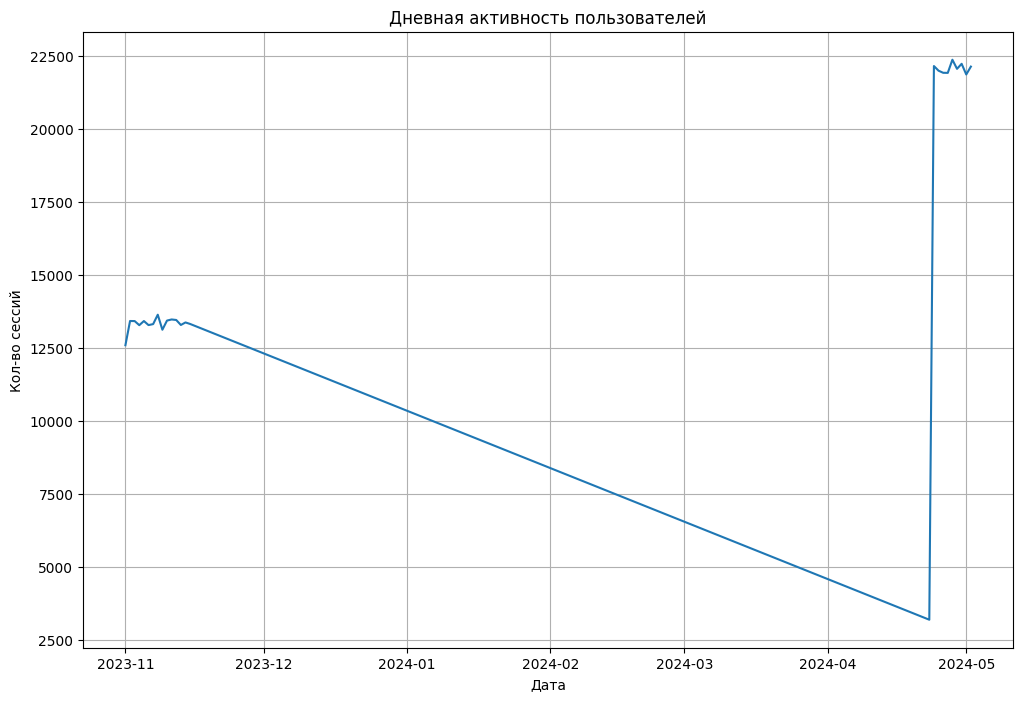

In [ ]:
day = df['datetime'].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 8))
day.plot(kind='line')
plt.title('Дневная активность пользователей')
plt.xlabel('Дата')
plt.ylabel('Кол-во сессий')
plt.grid(True)
plt.show()

# неравномерная динамика активности. Плюс даты отстоят друг от друга далеко

Раскроем правду. Изменение продукта касалось адаптации страницы отеля под его регион. Например, в южных регионах пользователям на странице отеля предлагались активности для пляжного отдыха, а в северном и центральном регионе сразу подбирались ближайшие экскурсии и так далее.

__в) [5 баллов]__ Проанализируйте, как ведут себя конверсии в страницу оплаты и в оплату в разных регионах? Опишите выводы.

In [ ]:
conv_reg= df.groupby('district').agg(
    users=('user_id', 'count'),
    payment_page_users=('payment_page', 'sum'),
    payment_users=('payment', 'sum')
).reset_index()

conv_reg['conv_to_payment_page'] = round(conv_reg['payment_page_users'] / conv_reg['users'] * 100, 2)
conv_reg['conv_to_payment'] = round(conv_reg['payment_users'] / conv_reg['users'] * 100, 2)

In [ ]:
conv_reg

,district,users,payment_page_users,payment_users,conv_to_payment_page,conv_to_payment
0,Дальневосточный федеральный округ,8057,1412,2492,17.53,30.93
1,Приволжский федеральный округ,60333,38017,18205,63.01,30.17
2,Северо-Западный федеральный округ,50071,35252,13416,70.40,26.79
3,Сибирский федеральный округ,16072,4983,4637,31.00,28.85
4,Уральский федеральный округ,26189,11485,8112,43.85,30.97
5,Центральный федеральный округ,120336,109514,33426,91.01,27.78
6,Южный федеральный округ,120749,97407,37137,80.67,30.76


**Ответ:** от региона к региону очень различные результаты. Аномалия на Дальновосточном ФО - почти никто не доходит до оплаты, но из тех, кто дошел - платят с самой высокой вероятностью. Самая высокая вовлеченность для Центрального и Южного ФО, при этом для Южного конверсия в оплаты выше, а для Центрального - больше во вход, ниже в оплаты. Уральский - устойчивый. Сибирь и ДВ хуже всего по входам.

__г) [5 баллов]__ Проанализируйте, улучшилась ли воронка для пользователей в тестовой группе по сравнению с контрольной вне зависимости от региона? Опишите выводы.

In [ ]:
df.groupby('group').payment_page.mean()

,payment_page
group,
control,0.756999
test,0.726803


In [ ]:
df.groupby('group').payment.mean()

,payment
group,
control,0.250170
test,0.333885


**Ответ:** среднее сильно улучшились по оплатам, а по просмотрам даже ухудшилось.

__д) [5 баллов]__ Проанализируйте распределение интересов пользователей в тестовой и контрольной группе. Какими регионами они интересовались? Изменились ли их предпочтения?

In [ ]:
# посмотрим разницу для регионов

conv_by_group = df.groupby(['district', 'group']).agg(
    users=('user_id', 'count'),
    payment_page_users=('payment_page', 'sum'),
    payment_users=('payment', 'sum')
).reset_index()

conv_by_group['conv_to_payment_page_%'] = round(conv_by_group['payment_page_users'] / conv_by_group['users'] * 100, 2)
conv_by_group['conv_to_payment_%'] = round(conv_by_group['payment_users'] / conv_by_group['users'] * 100, 2)

conv_pivot = conv_by_group.pivot(index='district', columns='group',
                                  values=['conv_to_payment_page_%', 'conv_to_payment_%'])

conv_pivot.columns = [f'{metric}_{group}' for metric, group in conv_pivot.columns]
conv_pivot = conv_pivot.reset_index()


conv_pivot

,district,conv_to_payment_page_%_control,conv_to_payment_page_%_test,conv_to_payment_%_control,conv_to_payment_%_test
0,Дальневосточный федеральный округ,10.01,20.01,23.21,33.48
1,Приволжский федеральный округ,60.00,65.00,25.21,33.45
2,Северо-Западный федеральный округ,70.00,72.00,25.17,33.21
3,Сибирский федеральный округ,30.00,32.00,24.63,33.03
4,Уральский федеральный округ,39.99,45.00,24.12,33.01
5,Центральный федеральный округ,90.00,93.00,25.08,33.12
6,Южный федеральный округ,80.00,81.00,24.93,33.64


**Ответ:** а вот теперь видно, что для каждого региона в отдельности значения улучшились.

Если вы все сделали правильно, то у вас получился противоречивые ответы в пунктах 3 и 4. Вы попали в ловушку Парадокса Симпсона. Подробнее о нем можно почитать [здесь](https://ru.wikipedia.org/wiki/Парадокс_Симпсона)

<img src="https://github.com/hse-econ-data-science/andan_2023/blob/main/hw/hw04/images/simpson.jpg?raw=true" width="350" align='center'>

__е) [4 балла]__ Теперь, когда вы все узнали, опишите кратко почему вы получили противоречивый результат в пунктах 3 и 4 (1 балл)

**Ваш ответ:** среднее по всей выборке - это не среднее по регионам, а взвешенное среднее. Оно зависит также от распределения пользователей между регионами. Может быть такое, что в тестовую выборку попало больше регионов с низкой конверсией. Тогда, несмотря на улучшение для каждого региона, среднее будет ниже, ведь количество случаев вхождения таких элементов увеличилось.

## Задача №3: Не подглядывать! (50 баллов)

<img src="https://github.com/hse-econ-data-science/andan_2023/blob/main/hw/hw04/images/trump.png?raw=true" width="500" align='left'>

На американских выборах 2020 года в некоторых штатах проходила очень конкурентная борьба между кандидатами. По мере подсчета голосов перевес в голосах склонялся то в пользу демократов, то в пользу республиканцев. И вот, в один из таких моментов, когда чаша весов склонилась в пользу республиканцев, Д. Трамп написал в твиттер "stop the count!", что означало призыв к остановке подсчета голосов.

_Здесь у вас мог возникнуть вопрос, и зачем нам это?_

Ответ очень прост. В этой ситуации всем очевидно, что призыв Трампа не мог быть осуществлен, то есть прерывать подсчет голосов раньше времени кажется довольно глупым способом выявления победителя. И вот абсолютно такой же способ принятия решения есть и в А/Б-тестах, только теперь многим аналитикам он уже кажется не столь очевидным, что приводит к существенным ошибкам в заключении выводов.

_Решив эту задачу, мы познакомимся с такой проблемой подробнее и поймем, как не стоит делать, когда вы запускаете А/Б-тест._

Чтобы понять, в чем же именно заключается проблема, мы с вами будем проводить симуляции А/Б-тестов. Это когда мы генерируем данные уже со знаниями, как эти данные устроены. А затем, запуская процедуру проверки гипотез над такими симулированными данными, мы будем оценивать, что происходит на практике (при запуске А/Б-теста).

На практике же всегда неизвестно, как устроены данные, и проводя А/Б-тест мы пытаемся зафиксировать различия. Еще раз, здесь же мы будем знать об устройстве данных, а затем будем смотреть на поведение А/Б-теста, то есть как будто бы смотреть на тест с обратной стороны.

_Перед тем как идти дальше, остановитесь здесь и еще раз зафиксируйте это!_

__а) [10 баллов]  Подсчет размера выборки для А/Б-теста__

Предположим, что вы хотите провести А/Б-тест внутри вашего приложения. Вы выбрали некоторую метрику $X$ – случайную величину из нормального распределения с мат. ожиданием $100$ у.е. и стандартным отклонением $40$ у.е – это ваш бейзлайн (группа А). Рассчитайте, сколько дней вам нужно крутить такой А/Б-тест, если:

1. Вы ожидаете получить минимальный размер эффекта в $5$ у.е.;
2. Вы хотите зафиксировать ошибку первого рода на уровне $\alpha=5\%$, а ошибку второго рода на уровне $\beta=20\%$;
3. Вы точно знаете, что в группе Б стандартное отклонение метрики составляет также $20$ у.е.
4. Посещаемость вашего приложения ежедневно составляет $200$ пользователей, и вы готовы раскатить тест на $100\%$ трафика.

Формула для расчета числа наблюдений _для одной группы_:

$$
n_{\text{one group}} = \frac{(\sigma_A^2 + \sigma_B^2) \cdot (z_{1-\frac{\alpha}{2}} + z_{1-\beta})^2}{MDE^2},
$$

__Подсказка:__ Помните, что после получения общего числа наблюдений вам нужно выразить это в дни! Вы должны получить целое число. Также будьте аккуратны с подсчетом трафика и кол-ва наблюдений – обратите внимание, со скольким числом групп вы работаете!

In [ ]:
import math
import numpy as np
from scipy.stats import norm

sigma_A = 40
sigma_B = 20
alpha = 0.05
beta = 0.20
min_eff = 5

z_alpha = norm.ppf(1 - alpha / 2)
z_beta = norm.ppf(1 - beta)

In [ ]:
n_one_group = ((sigma_A ** 2 + sigma_B ** 2) * (z_alpha + z_beta) ** 2) / (min_eff ** 2)
n_one_group = math.ceil(n_one_group)

# Кол-во дней = общее число пользователей / пользователей в день
days = math.ceil(2 * n_one_group / 200)

n_one_group, 2 * n_one_group, days

(628, 1256, 7)

__б) [20 баллов] Симуляция А/Б-теста__

Теперь нам нужно запустить А/Б-тест. Для этого:

1. Сгенерируйте выборку данных из нормального распределения для группы А и Б в конкретный один день. Считайте, что в группе Б математическое ожидание составляет $105$ у.е., то есть с учетом размера вашего минимального ожидаемого эффекта из предыдущего пункта.

In [ ]:
np.random.seed(42)

n_group = 100 # 100+100=200
mu_A = 100
mu_B = 105
sigma_A = 40
sigma_B = 20

group_A = np.random.normal(loc=mu_A, scale=sigma_A, size=n_group)
group_B = np.random.normal(loc=mu_B, scale=sigma_B, size=n_group)

print("Группа A: mean =", round(group_A.mean(), 2), ", std =", round(group_A.std(ddof=1), 2))
print("Группа B: mean =", round(group_B.mean(), 2), ", std =", round(group_B.std(ddof=1), 2))

Группа A: mean = 95.85 , std = 36.33
Группа B: mean = 105.45 , std = 19.07


2. Теперь представим, что наш тест был запущен $X$ дней. Напишите функцию, которая за этот период теста собирает в `DataFrame` следующие данные на каждый день теста:
    1. среднее метрики в группе А
    2. среднее метрики в группе Б
    3. p-value, посчитанное с помощью t-test – можно воспользоваться встроенной функцией `scipy.stats.ttest_ind`
    
    Соберите `DataFrame` для $X=50$.
    
__Подсказка:__ Среднее для 1-го дня должно считаться по пользователям, пришедших в первый день, для второго дня – по пользователям, пришедшим в первый и второй день и т.д. То есть накопленным итогом за каждый день теста.

In [ ]:
from scipy.stats import ttest_ind

def simulate_ab(X,
                n_per_group=100,
                mu_A=100, sigma_A=40,
                mu_B=105, sigma_B=20):
    np.random.seed(42)

    all_A, all_B = [], []
    results = []

    for day in range(1, X + 1):
        daily_A = np.random.normal(loc=mu_A, scale=sigma_A, size=n_per_group)
        daily_B = np.random.normal(loc=mu_B, scale=sigma_B, size=n_per_group)

        # добавление данных за день цикла
        all_A.extend(daily_A)
        all_B.extend(daily_B)

        t_stat, p_val = ttest_ind(all_A, all_B, equal_var=False)

        results.append({
            "day": day,
            "mean_A": np.mean(all_A),
            "mean_B": np.mean(all_B),
            "p_value": p_val
        })

    return pd.DataFrame(results)

In [ ]:
df_ab = simulate_ab(50)
print(df_ab.head())

   day      mean_A      mean_B   p_value
0    1   95.846139  105.446092  0.020617
1    2   99.220995  106.291447  0.023995
2    3   98.733937  105.092261  0.014382
3    4   99.291391  105.038393  0.011438
4    5  101.262306  105.142129  0.053350


3. На основе `DataFrame` из предыдущего пункта постройте график динамики среднего в группе А и в группе Б по дням теста. Отложите вертикальную линию на этом же графике, показывающую кол-во дней, посчитанных в пункте 1. Сделайте эту линию пунктирной и измените цвет, который вам больше нравится.

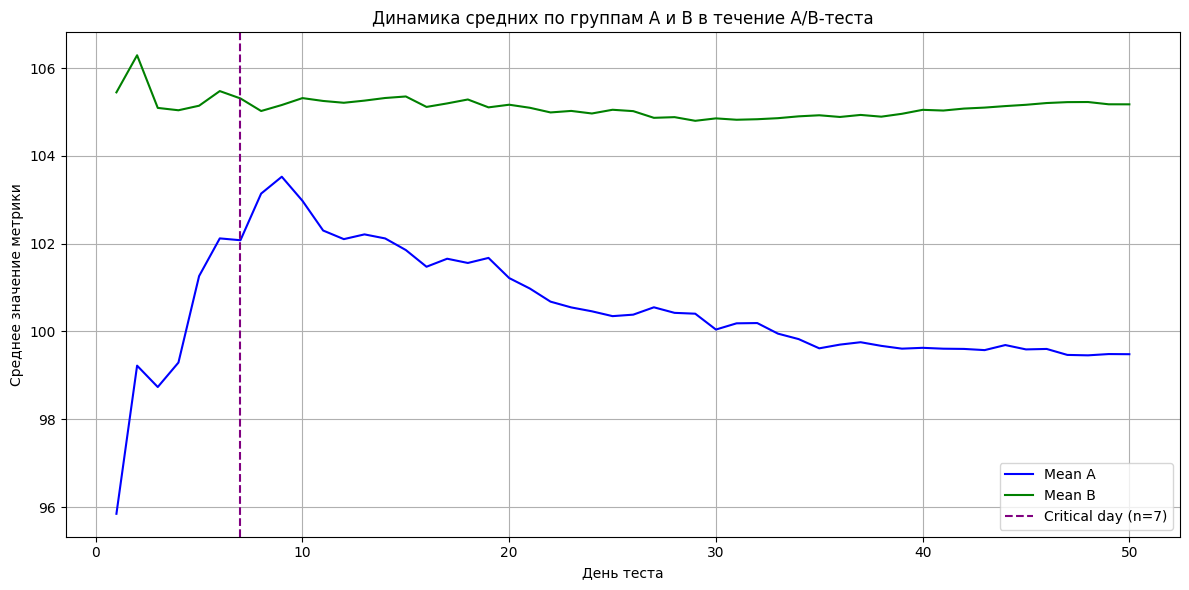

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_ab['day'], df_ab['mean_A'], label='Mean A', color='blue')
plt.plot(df_ab['day'], df_ab['mean_B'], label='Mean B', color='green')

# линия на 7 дне (значение days из А)
plt.axvline(x=7, linestyle='--', color='purple', label='Critical day (n=7)')

plt.title('Динамика средних по группам A и B в течение A/B-теста')
plt.xlabel('День теста')
plt.ylabel('Среднее значение метрики')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

4. На основе `DataFrame` из предыдущего пункта постройте график динамики p-value по дням теста. Отложите вертикальную линию на этом же графике, показывающую кол-во дней, посчитанных в пункте 1. Сделайте эту линию пунктирной и измените цвет, который вам больше нравится. Также отложите горизонтальную линию – ваш уровень значимости $\alpha$.

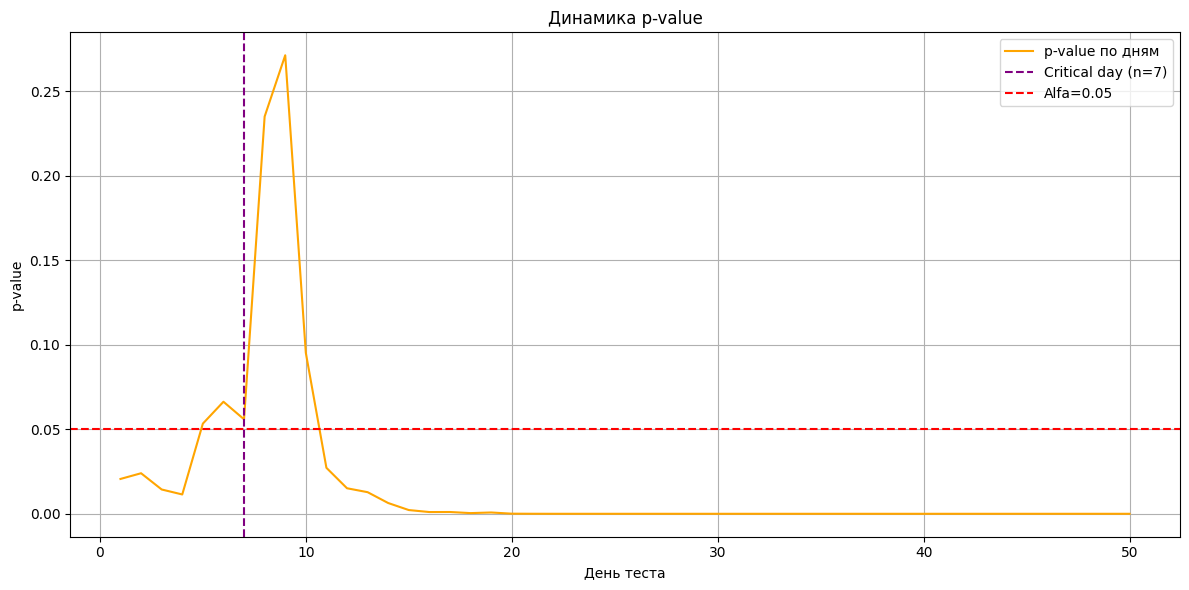

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_ab['day'], df_ab['p_value'], label='p-value по дням', color='orange')

plt.axvline(x=7, linestyle='--', color='purple', label='Critical day (n=7)')
plt.axhline(y=0.05, linestyle='--', color='red', label='Alfa=0.05')

plt.title('Динамика p-value')
plt.xlabel('День теста')
plt.ylabel('p-value')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

5. Перегенируруйте шаги 2-4 несколько раз, посмотрев на графики. Что вы видите? Что происходит с p-value в периодах:
    1. до кол-ва дней, посчитанных по формуле из п.1
    2. в точке кол-ва дней, посчитанных по формуле из п.1
    3. после кол-ва дней, посчитанных по формуле из п.1
    
    Опишите выводы максимально подробно.

<ipython-input-22-a2b388133a8a>:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1)


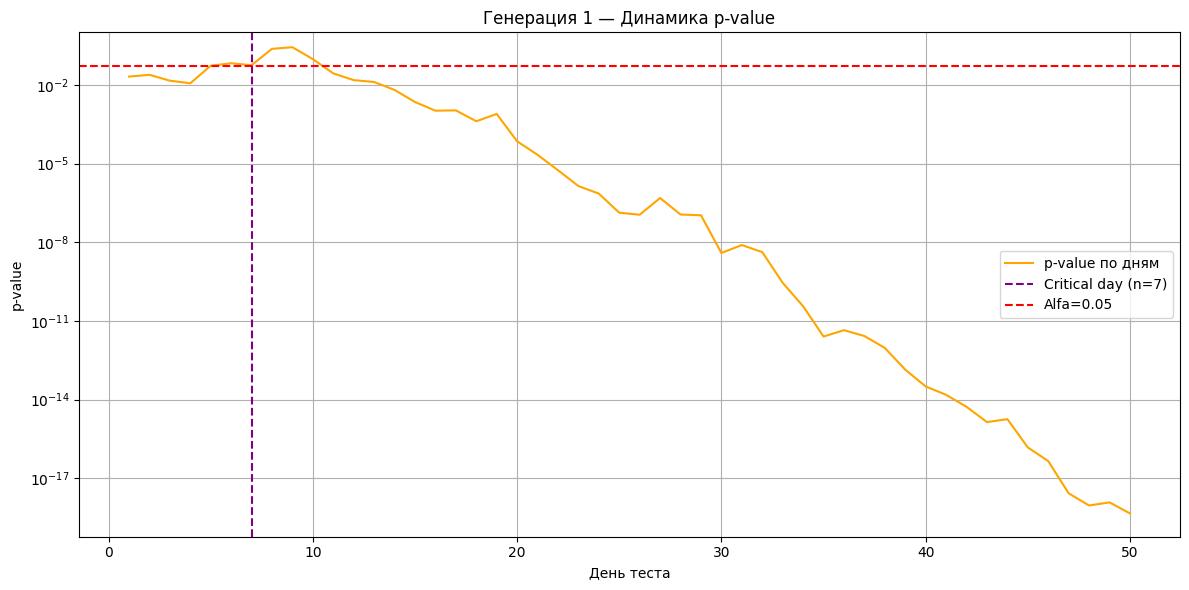

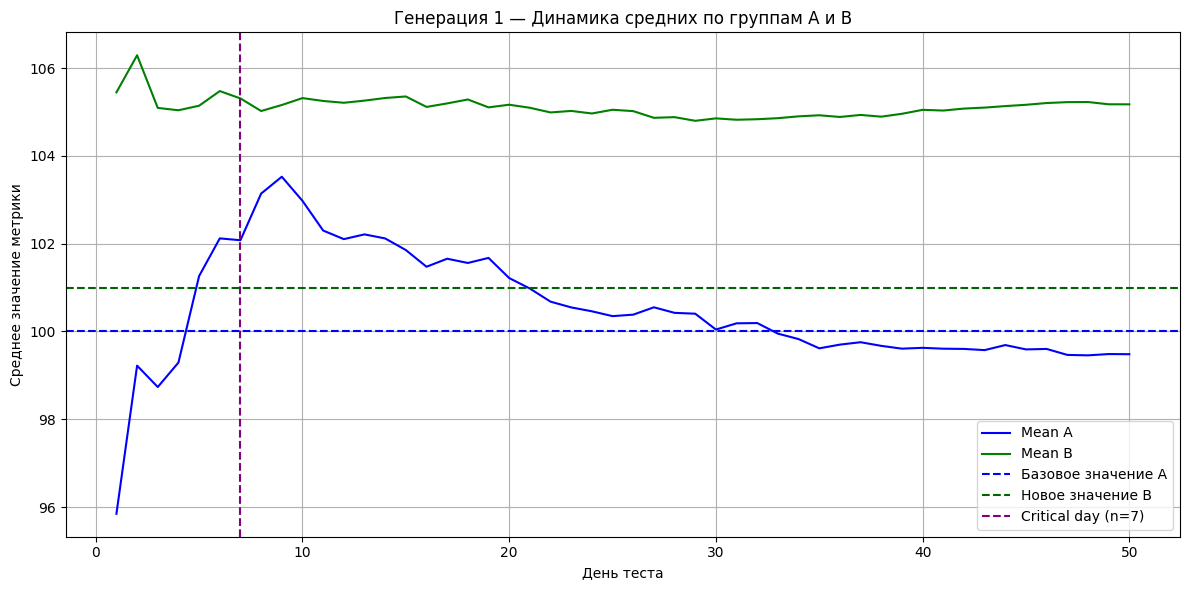

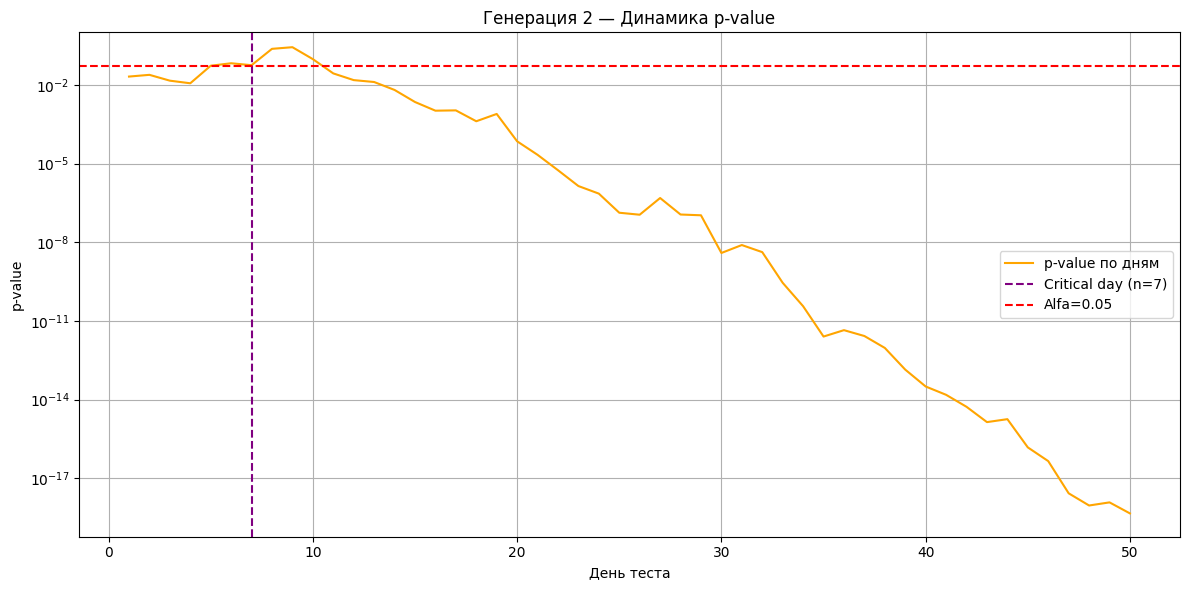

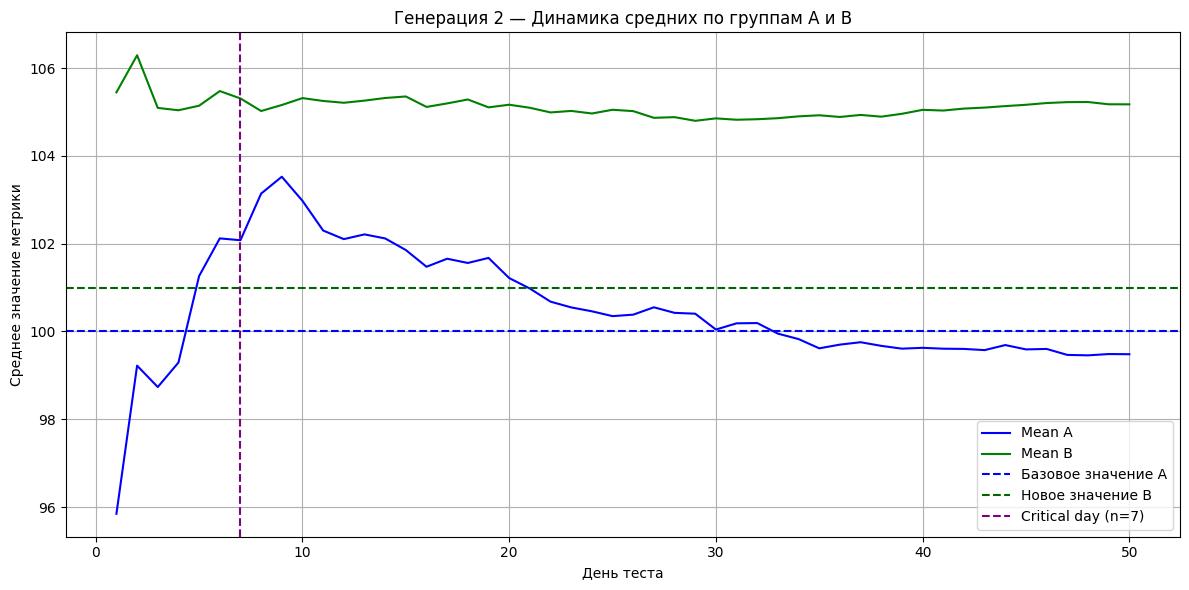

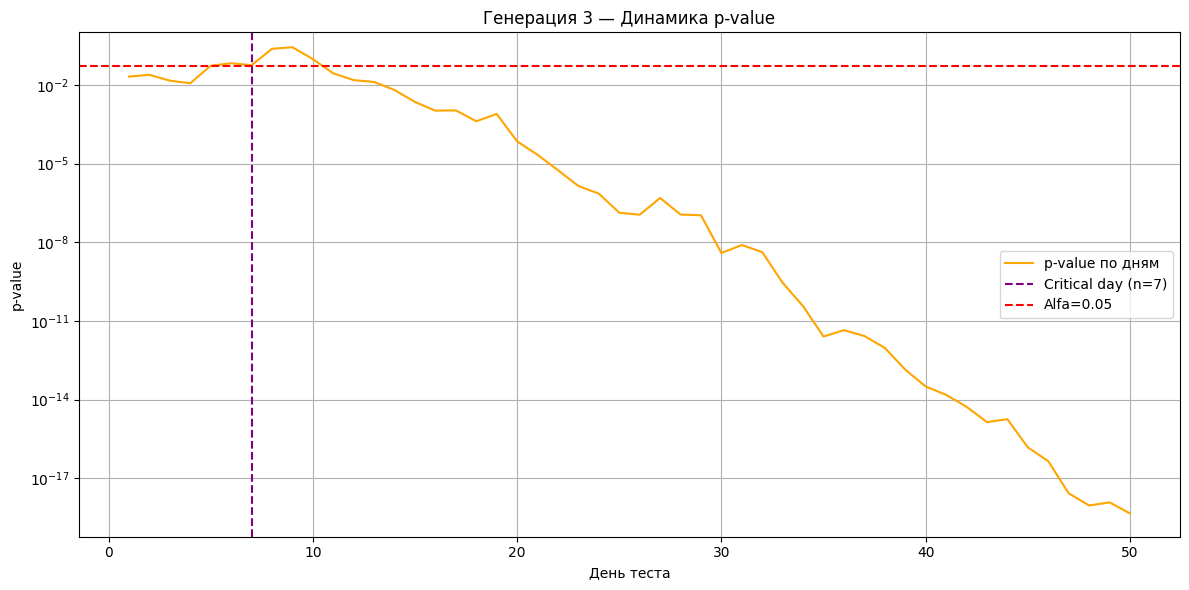

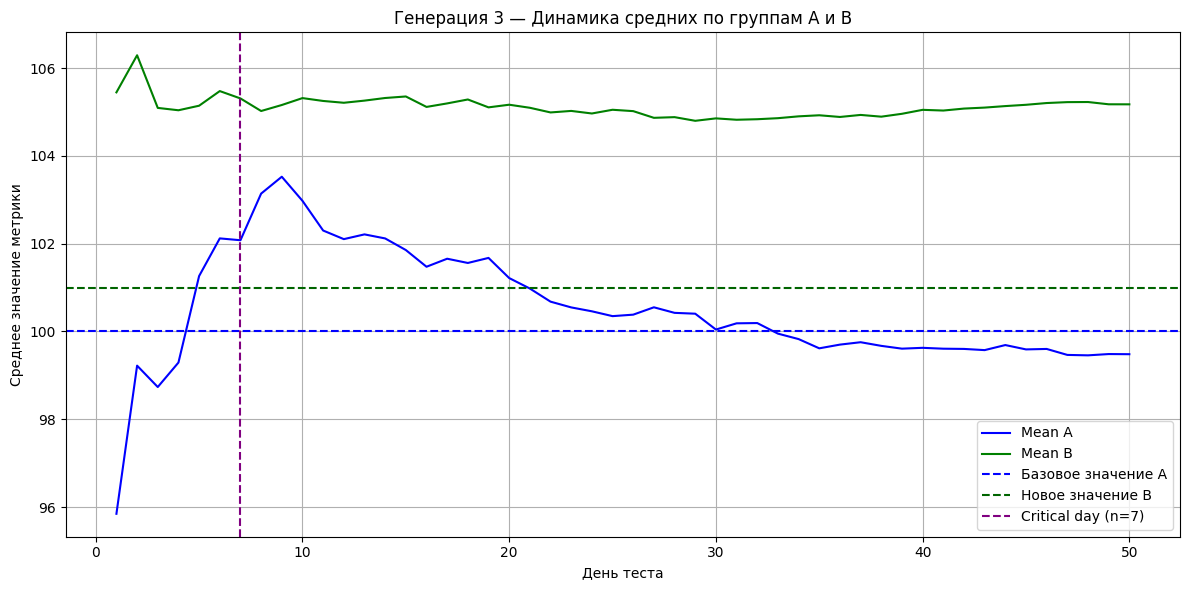

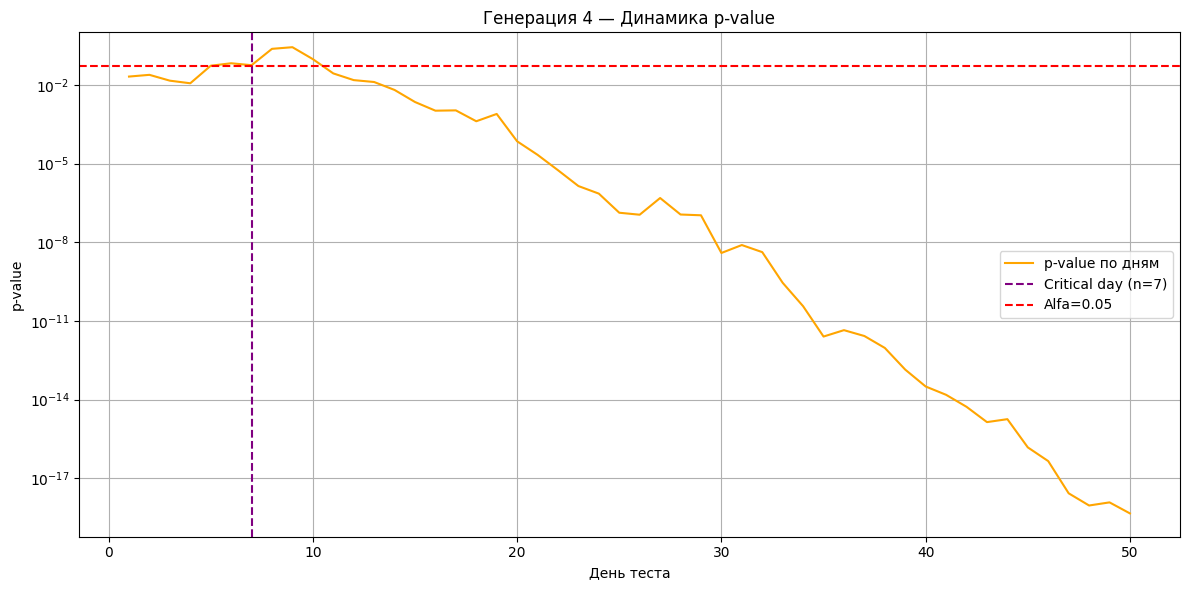

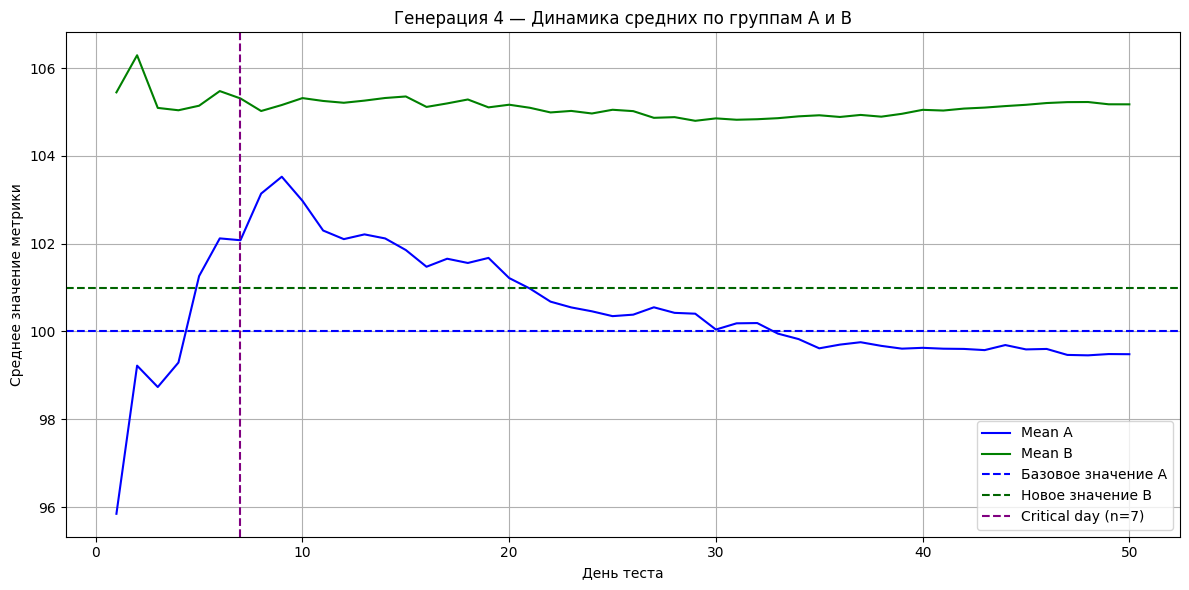

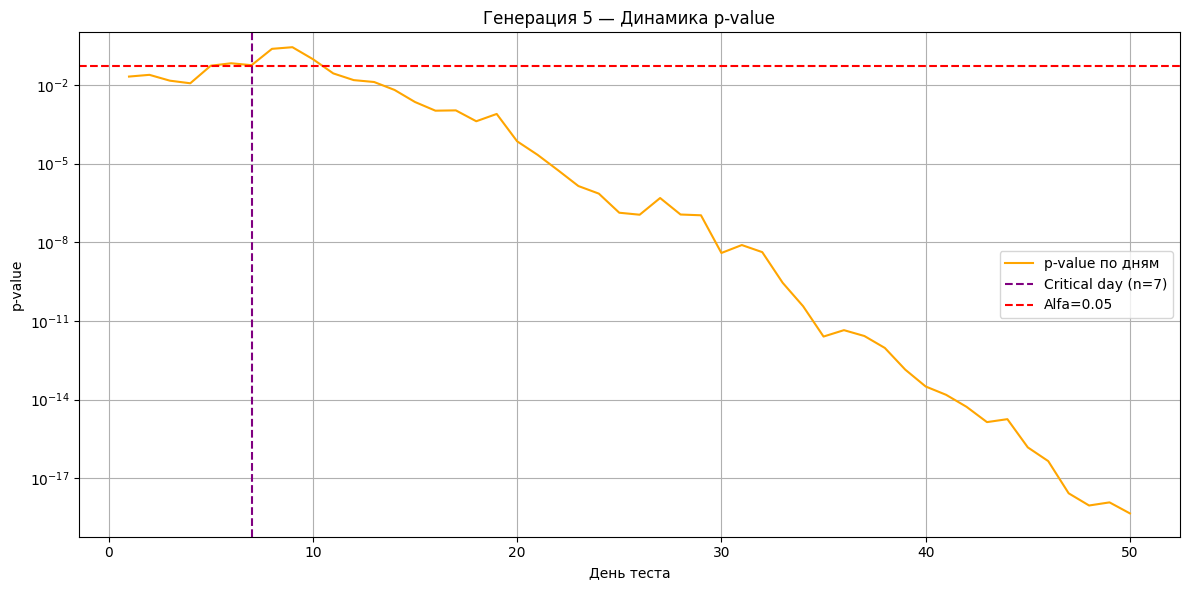

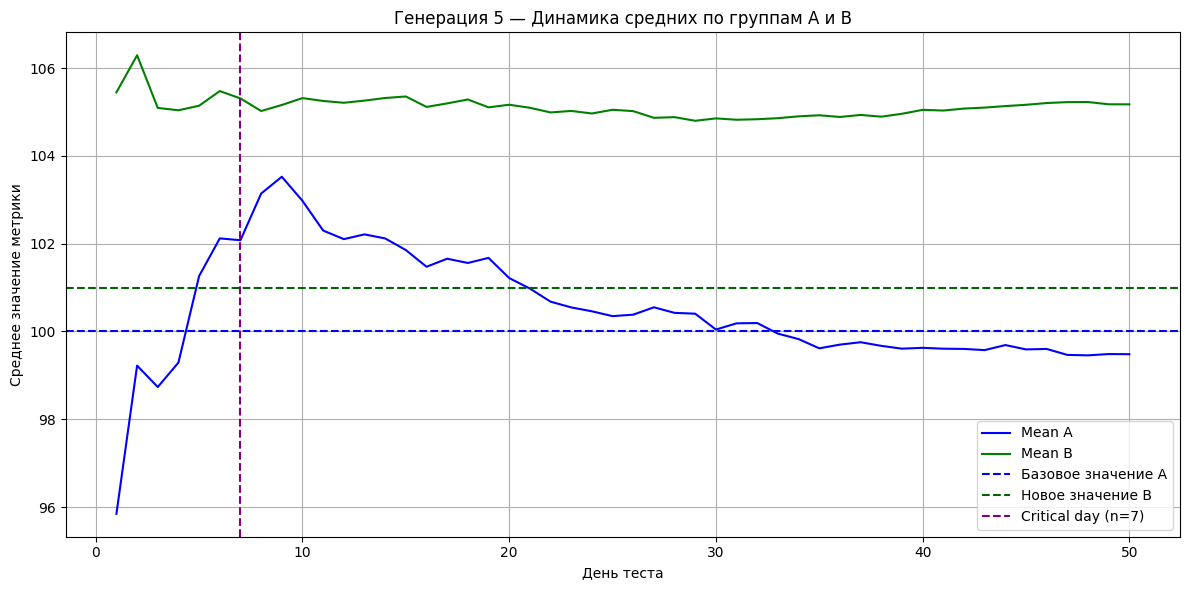

In [ ]:
all_ab = []

ab_df1 = simulate_ab(50)
all_ab.append(ab_df1)

ab_df2 = simulate_ab(50)
all_ab.append(ab_df2)

ab_df3 = simulate_ab(50)
all_ab.append(ab_df3)

ab_df4 = simulate_ab(50)
all_ab.append(ab_df4)

ab_df5 = simulate_ab(50)
all_ab.append(ab_df5)


for i, df in enumerate(all_ab):
    plt.figure(figsize=(12, 6))
    plt.plot(df['day'], df['p_value'], label='p-value по дням', color='orange')
    plt.axvline(x=7, linestyle='--', color='purple', label='Critical day (n=7)')
    plt.axhline(y=0.05, linestyle='--', color='red', label='Alfa=0.05')
    plt.yscale('log')

    plt.title(f'Генерация {i+1} — Динамика p-value')
    plt.xlabel('День теста')
    plt.ylabel('p-value')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(df['day'], df['mean_A'], label='Mean A', color='blue')
    plt.plot(df['day'], df['mean_B'], label='Mean B', color='green')
    plt.axhline(y=mu_A, color='blue', linestyle='--', label='Базовое значение A')
    plt.axhline(y=mu_B, color='darkgreen', linestyle='--', label='Новое значение B')
    plt.axvline(x=7, linestyle='--', color='purple', label='Critical day (n=7)')

    plt.title(f'Генерация {i+1} — Динамика средних по группам A и B')
    plt.xlabel('День теста')
    plt.ylabel('Среднее значение метрики')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

**Ответ:** В первые 7 дней нет устойчивой динамики, p_value выше 0.05 преимущественно. После 7 дня происходят резкие последние скачки в средних и на графике p_value, затем постепенно идут на спад. Разница между группами становится особенно явной после 20 дня. Значения стабилизируются с увеличением количества дней.

6. Теперь предположим, что мы поменяли наш $MDE$ до $1$ у.е. То есть мат. ожидание в группе А осталось по-прежнему $100$, а вот в группе Б теперь $101$. Перегенерируйте пункты 2-4 для измененного $MDE$, при этом кол-во дней в п.1 не пересчитывайте. Что происходит с p-value? Сделайте выводы.

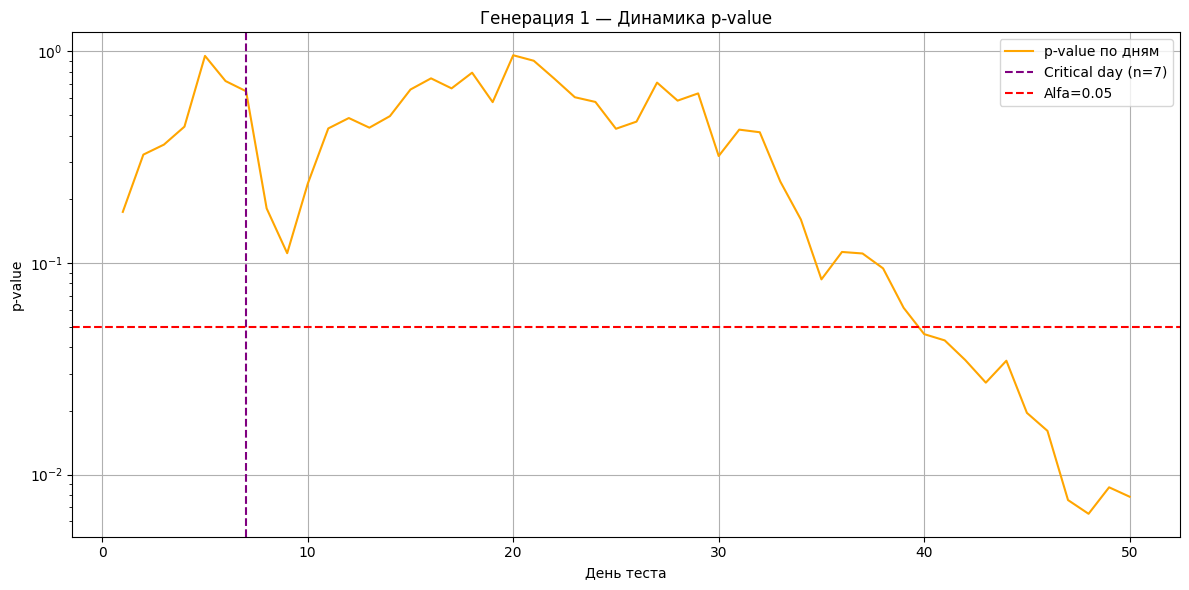

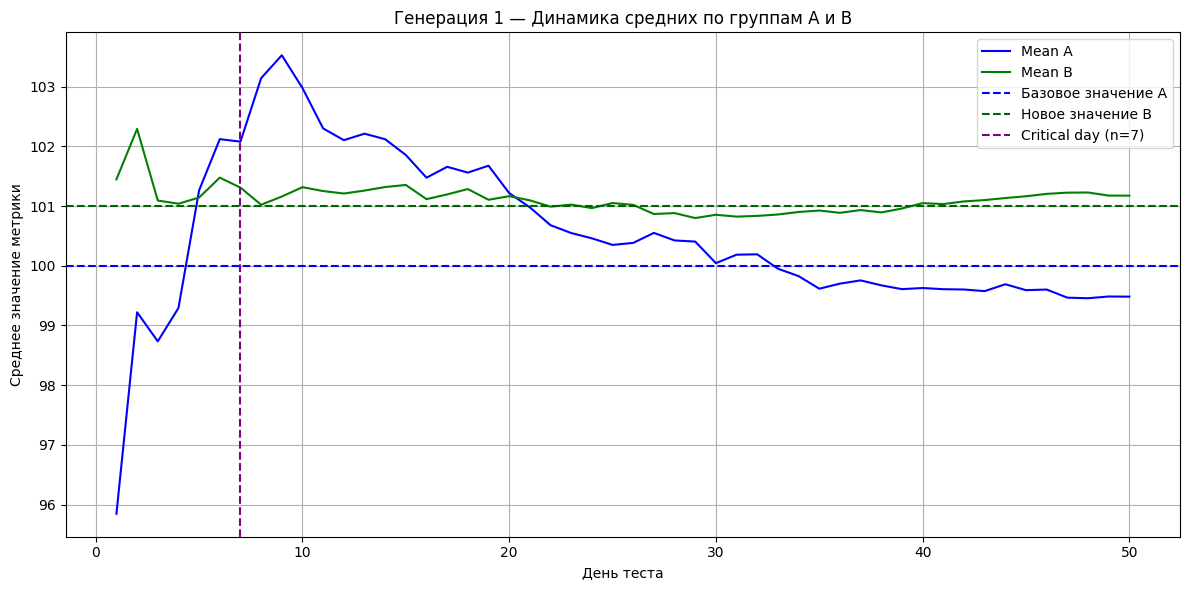

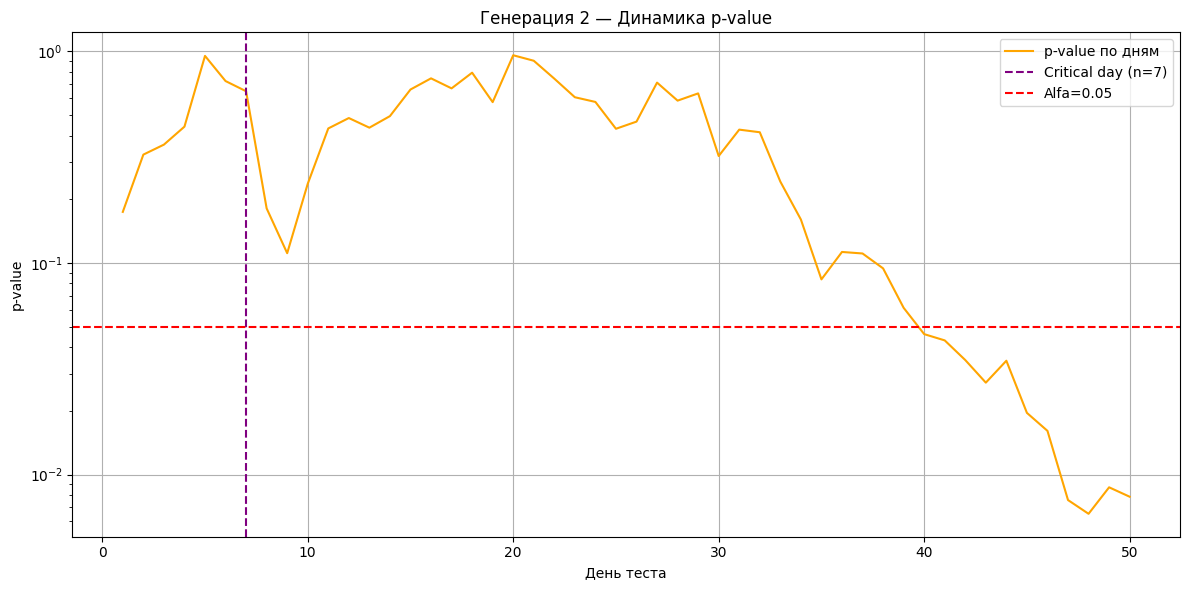

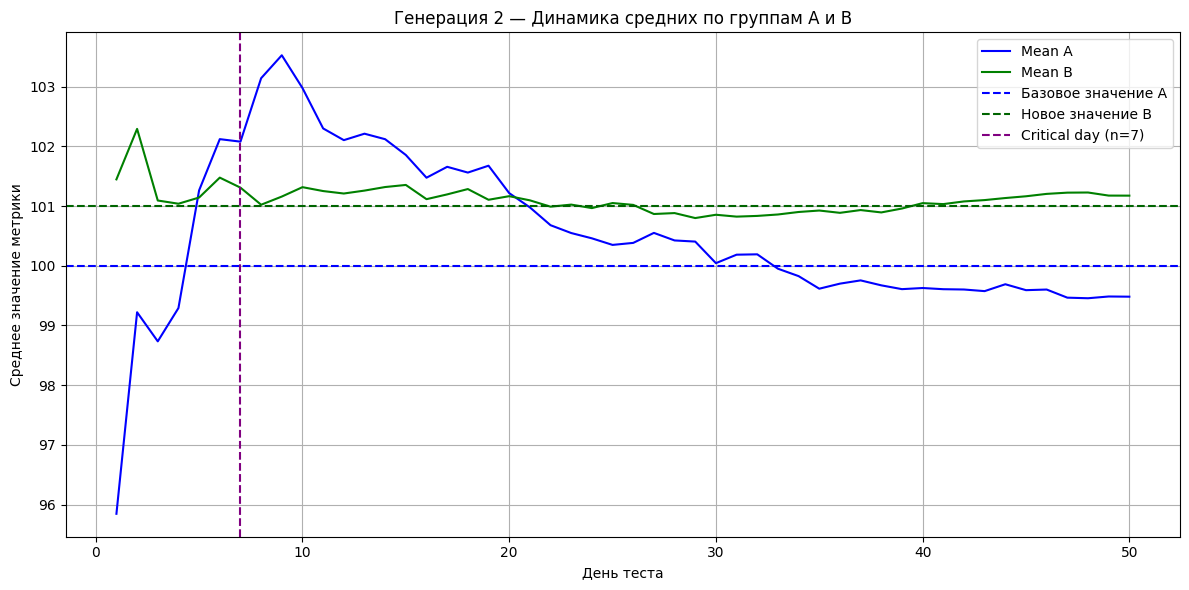

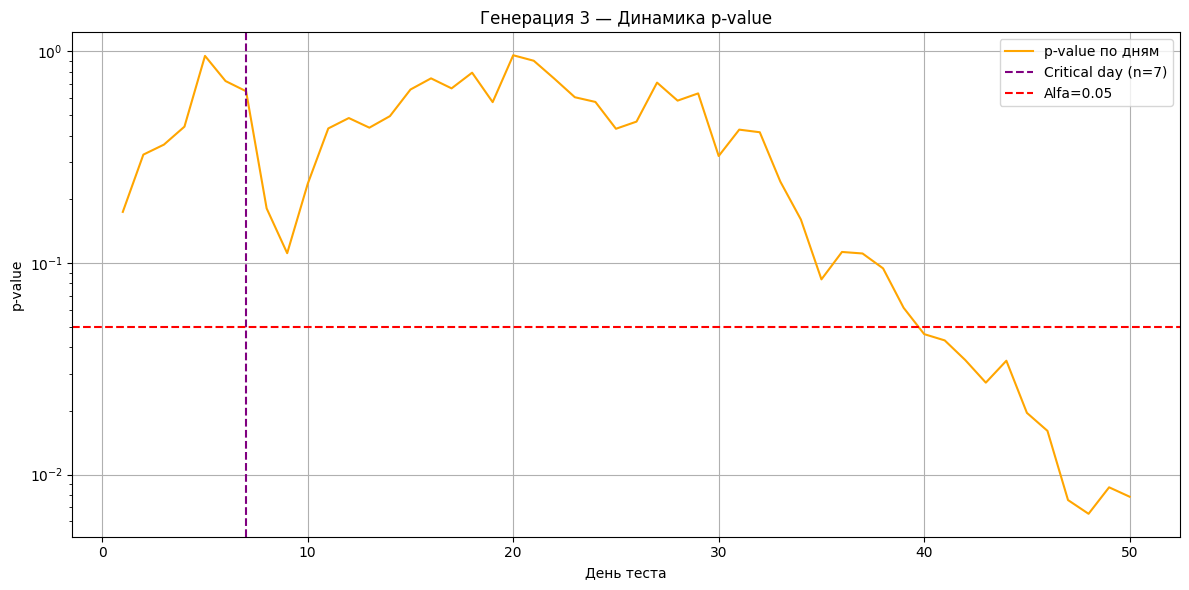

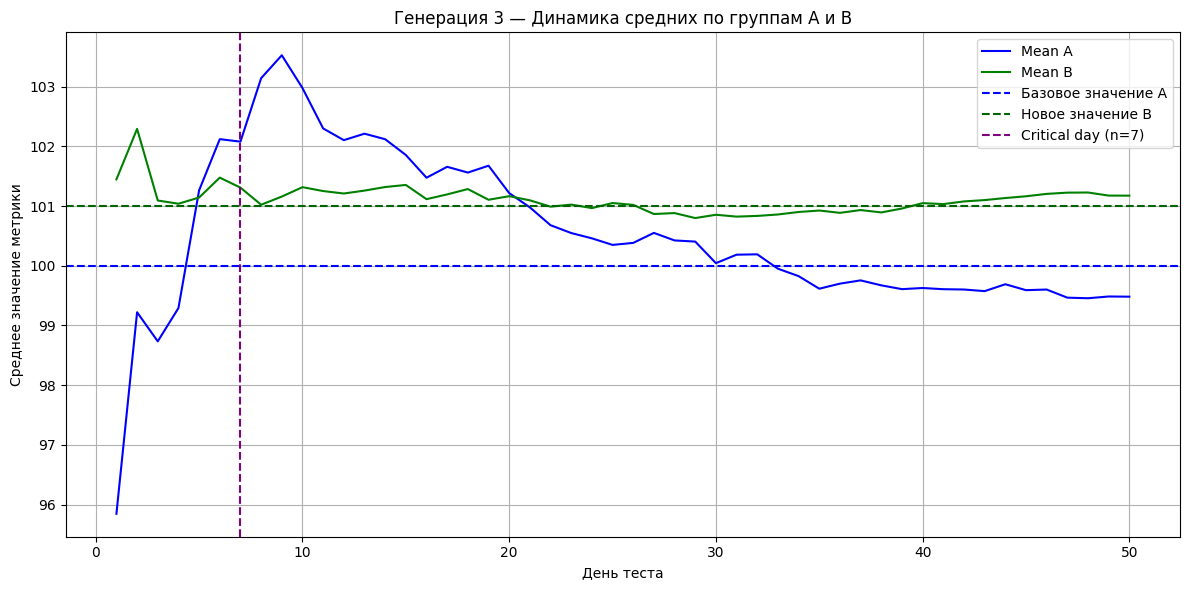

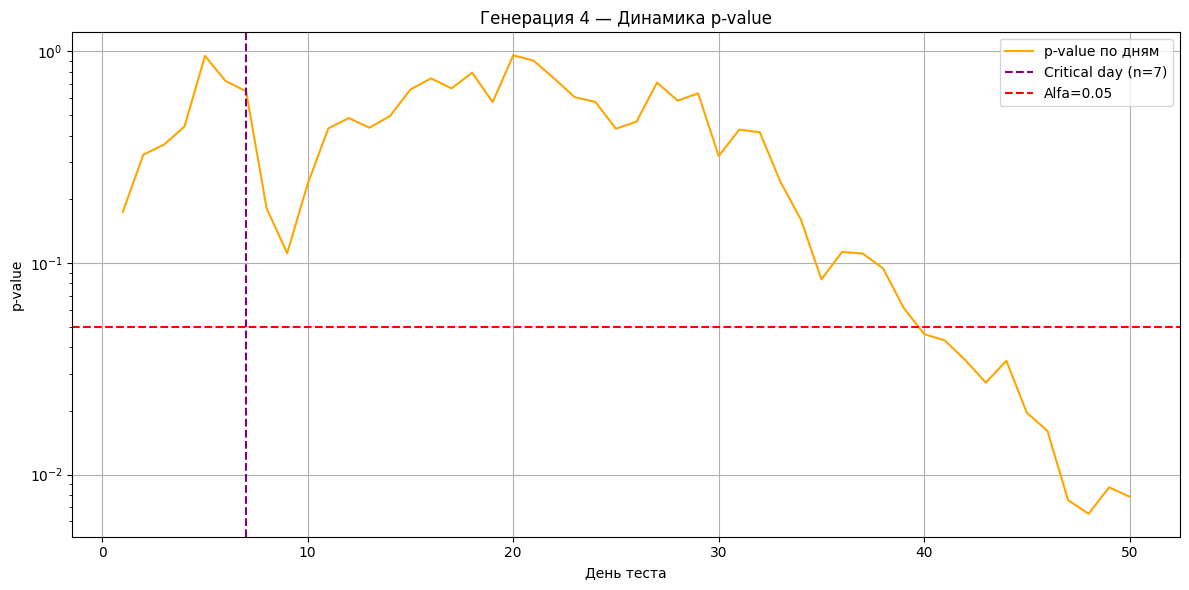

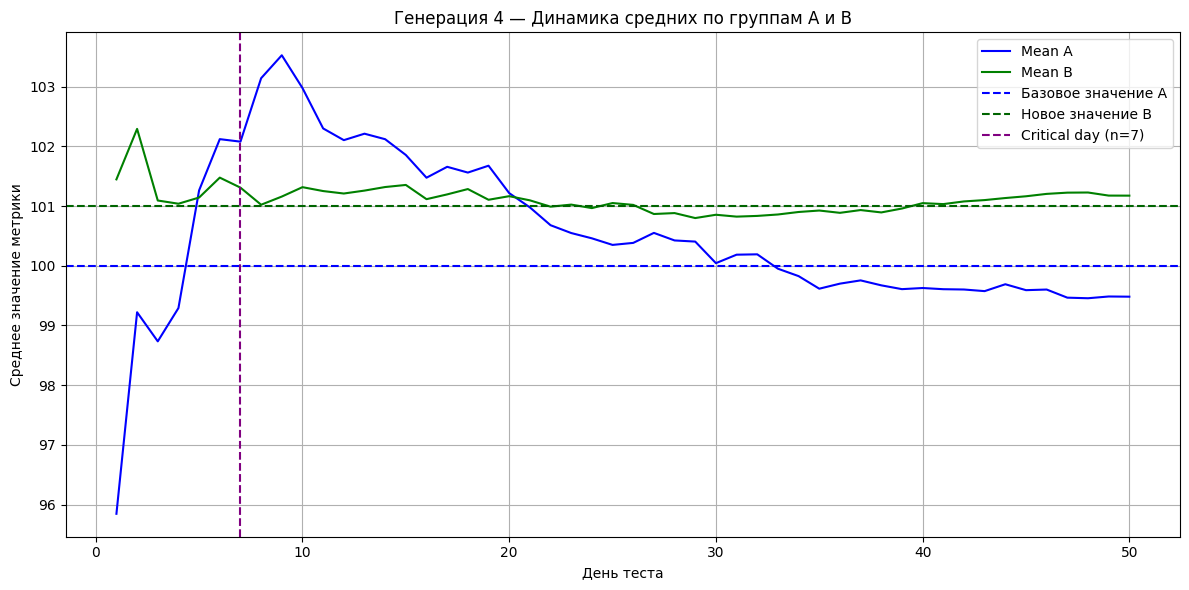

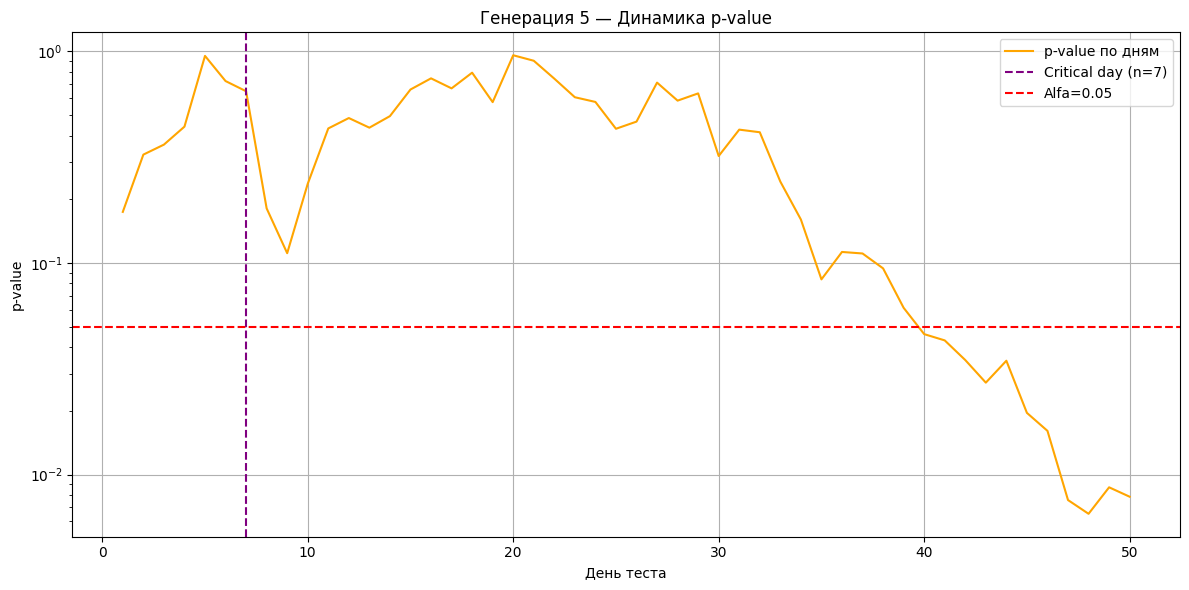

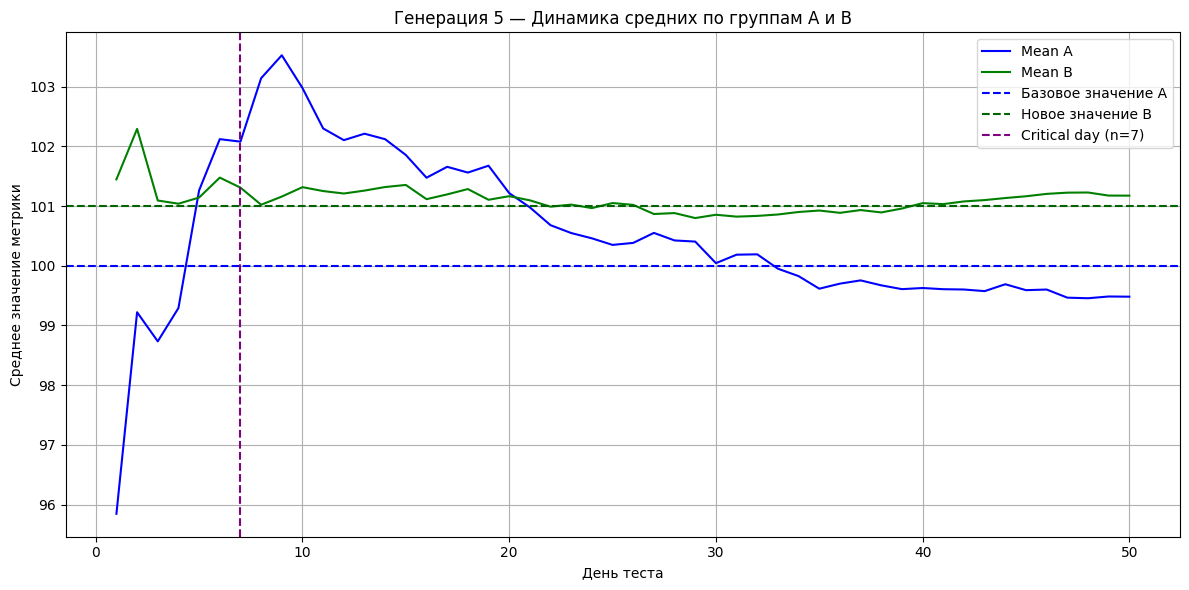

In [ ]:
all_ab = []

ab_df1 = simulate_ab(50, mu_B = 101)
all_ab.append(ab_df1)

ab_df2 = simulate_ab(50, mu_B = 101)
all_ab.append(ab_df2)

ab_df3 = simulate_ab(50, mu_B = 101)
all_ab.append(ab_df3)

ab_df4 = simulate_ab(50, mu_B = 101)
all_ab.append(ab_df4)

ab_df5 = simulate_ab(50, mu_B = 101)
all_ab.append(ab_df5)

for i, df in enumerate(all_ab):
    plt.figure(figsize=(12, 6))
    plt.plot(df['day'], df['p_value'], label='p-value по дням', color='orange')
    plt.axvline(x=7, linestyle='--', color='purple', label='Critical day (n=7)')
    plt.axhline(y=0.05, linestyle='--', color='red', label='Alfa=0.05')
    plt.yscale('log')

    plt.title(f'Генерация {i+1} — Динамика p-value')
    plt.xlabel('День теста')
    plt.ylabel('p-value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(df['day'], df['mean_A'], label='Mean A', color='blue')
    plt.plot(df['day'], df['mean_B'], label='Mean B', color='green')
    plt.axhline(y=mu_A, color='blue', linestyle='--', label='Базовое значение A')
    plt.axhline(y=mu_B, color='darkgreen', linestyle='--', label='Новое значение B')
    plt.axvline(x=7, linestyle='--', color='purple', label='Critical day (n=7)')

    plt.title(f'Генерация {i+1} — Динамика средних по группам A и B')
    plt.xlabel('День теста')
    plt.ylabel('Среднее значение метрики')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

При заниженном MDE нужно перерассчитывать объём выборки.
Или быть готовым к тому, что статистическая значимость не будет достигнута, даже при реальном эффекте. P_value ожидаемо становится менее стабильным и принимает большие значения.

__в) [20 баллов] Симуляция А/А-теста__

Теперь представим, что изменений на самом деле никаких нету, то есть мат. ожидание в обоих группах $100$, а $MDE = 0$

1. И снова перегенерируйте вышесделанные пункты 2-4. Что происходит с p-value? Может ли оно оказаться ниже уровня значимости?

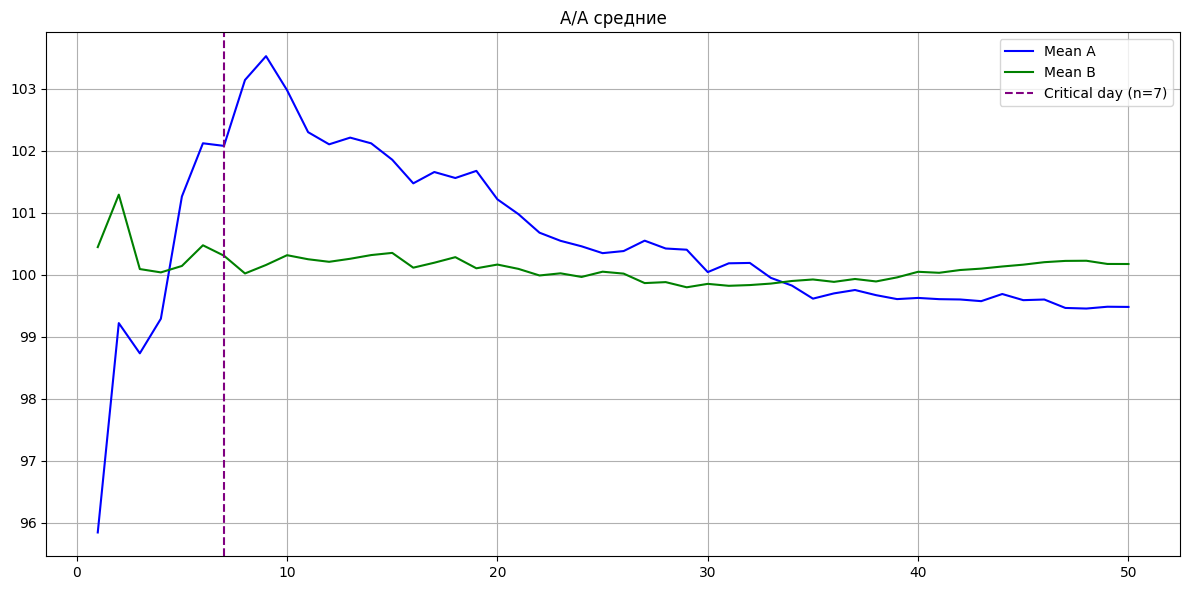

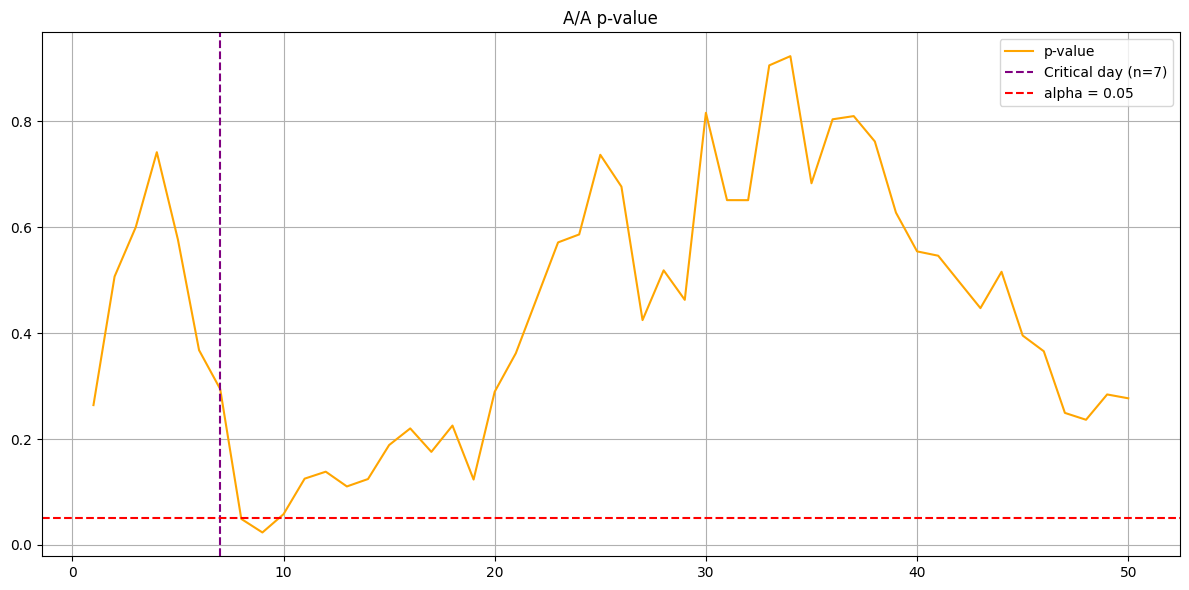

In [ ]:
def simulate_aa_test(X,
                     n_per_group=100,
                     mu=100, sigma_A=40, sigma_B=20,
                     seed=42):
    np.random.seed(seed)
    all_A, all_B = [], []
    results = []

    for day in range(1, X + 1):
        daily_A = np.random.normal(loc=mu, scale=sigma_A, size=n_per_group)
        daily_B = np.random.normal(loc=mu, scale=sigma_B, size=n_per_group)
        all_A.extend(daily_A)
        all_B.extend(daily_B)
        t_stat, p_val = ttest_ind(all_A, all_B, equal_var=False)
        results.append({
            "day": day,
            "mean_A": np.mean(all_A),
            "mean_B": np.mean(all_B),
            "p_value": p_val
        })
    return pd.DataFrame(results)

df_aa = simulate_aa_test(50)

plt.figure(figsize=(12, 6))
plt.plot(df_aa['day'], df_aa['mean_A'], label='Mean A', color='blue')
plt.plot(df_aa['day'], df_aa['mean_B'], label='Mean B', color='green')
plt.axvline(x=7, linestyle='--', color='purple', label='Critical day (n=7)')
plt.title('A/A средние')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_aa['day'], df_aa['p_value'], label='p-value', color='orange')
plt.axvline(x=7, linestyle='--', color='purple', label='Critical day (n=7)')
plt.axhline(y=0.05, linestyle='--', color='red', label='alpha = 0.05')
plt.title('A/A p-value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Ответ:** На АА-тесте не должно обнаруживаться значимых различий между выборками. В нашем случае p_val всего раз случайно принимает значение меньше 0.05. При этом видно, что даже при отсутствии реальной значимой разницы мы можем получить подобие эффекта.

2. Ну и напоследок, напишите функцию, которая генерирует p-value на последний день A/A теста. А затем запустите эту функцию $1000$ раз, собрав $1000$ значений p-value. Постройте гистограмму их распределения. Что вы видите?

__Подсказка:__ Для такой функции достаточно создать выборку один раз, изменив ее размер.

In [ ]:
def generate_aa(n=50, n_per_group=100, mu=100, sigma_A=40, sigma_B=20):
    size = n * n_per_group
    group_A = np.random.normal(loc=mu, scale=sigma_A, size=size)
    group_B = np.random.normal(loc=mu, scale=sigma_B, size=size)
    _, p_val = ttest_ind(group_A, group_B, equal_var=False)
    return p_val

np.random.seed(42)
p_values = [generate_aa() for _ in range(1000)]

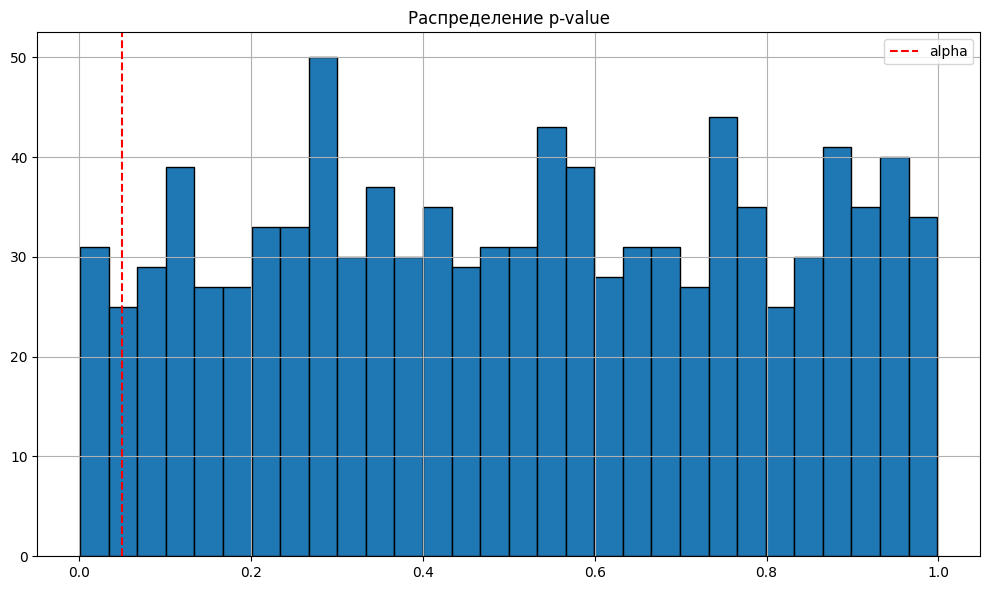

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(p_values, bins=30,  edgecolor='black')
plt.axvline(0.05, color='red', linestyle='--', label='alpha')
plt.title('Распределение p-value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


p-value распределены почти равномерно между 0 и 1 — так и надо, различий нет.Как раз 5% p-value попадают ниже 0.05 —  это буквально соответствует уровню ошибки первого рода (0.05).